<a href="https://colab.research.google.com/github/Safiullah7864/Student-s-Phone-Addiction-Affects-on-Productivity/blob/main/Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
df = pd.read_csv("/content/student_phone_addiction_affects_on_productivity(in).csv")

In [24]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,coffee_per_day,breaks_per_day,night_usage,distraction_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,7.377325,290.254742,NaN,2.0,1.0,0.0,7.852,Medium,29.587834
1,34.0,3.82,2.33,0.28,7.612689,270.571074,93.65,1.0,3.0,0.0,7.146,Medium,17.320665
2,29.0,3.57,1.64,5.21,6.143298,134.054219,100.00,0.0,5.0,0.0,2.962,Low,75.183980
3,25.0,10.27,4.37,4.28,4.012145,233.019834,94.71,2.0,2.0,1.0,8.791,Medium,31.133161
4,22.0,2.42,1.60,3.67,6.953253,19.381791,100.00,0.0,3.0,0.0,0.669,Low,54.640676


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    9531 non-null   float64
 1   daily_screen_time      9529 non-null   float64
 2   social_media_hours     9518 non-null   float64
 3   study_hours            9530 non-null   float64
 4   sleep_hours            9532 non-null   float64
 5   notifications_per_day  9531 non-null   float64
 6   focus_score            9528 non-null   float64
 7   coffee_per_day         9723 non-null   float64
 8   breaks_per_day         9707 non-null   float64
 9   night_usage            9800 non-null   float64
 10  distraction_score      9016 non-null   float64
 11  addiction_level        9517 non-null   object 
 12  productivity_score     9536 non-null   float64
dtypes: float64(12), object(1)
memory usage: 1015.8+ KB


In [26]:
df.nunique() #unique values of each coulumn

,0
age,25
daily_screen_time,4859
social_media_hours,4671
study_hours,4498
sleep_hours,9532
notifications_per_day,9489
focus_score,3702
coffee_per_day,3429
breaks_per_day,3707
night_usage,2


In [27]:
df.isnull().sum()  #total num of missing values in the column

,0
age,469
daily_screen_time,471
social_media_hours,482
study_hours,470
sleep_hours,468
notifications_per_day,469
focus_score,472
coffee_per_day,277
breaks_per_day,293
night_usage,200


<Axes: >

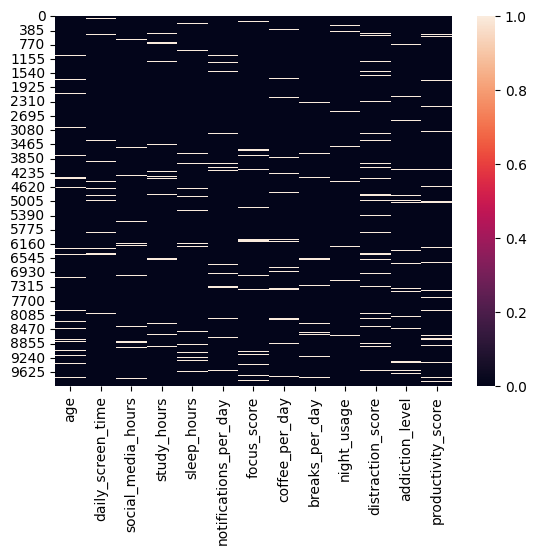

In [28]:
sns.heatmap((df.isnull()))   #Visualizes missing values in the dataset

In [29]:
df_upd = df.copy()   #Copy of the orignal datasets

In [30]:

num_cols = [
    "age","daily_screen_time","social_media_hours","study_hours",
    "sleep_hours","notifications_per_day","focus_score",
    "coffee_per_day","breaks_per_day","distraction_score",
    "productivity_score"
]

for col in num_cols:
    df_upd[col] = df_upd[col].fillna(df_upd[col].median())   #Fills missing numeric values using the median

df_upd["addiction_level"] = df_upd["addiction_level"].fillna(  #Fills missing values with mode
    df_upd["addiction_level"].mode()[0]
)

df_upd["night_usage"] = df_upd["night_usage"].fillna(  #Same as above
    df_upd["night_usage"].mode()[0]
)

In [31]:
df.isnull().sum()

,0
age,469
daily_screen_time,471
social_media_hours,482
study_hours,470
sleep_hours,468
notifications_per_day,469
focus_score,472
coffee_per_day,277
breaks_per_day,293
night_usage,200


In [32]:
df_upd.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
study_hours,0
sleep_hours,0
notifications_per_day,0
focus_score,0
coffee_per_day,0
breaks_per_day,0
night_usage,0


In [33]:
le = LabelEncoder()
df_upd["addiction_level"] = le.fit_transform(df_upd['addiction_level'])   #Convert Catogorical values(low,medium,high) into numeric values

In [34]:
#Removes less useful columns.
df_upd = df_upd.drop(["notifications_per_day", "coffee_per_day", "age"], axis=1)


df_upd.head()

,daily_screen_time,social_media_hours,study_hours,sleep_hours,focus_score,breaks_per_day,night_usage,distraction_score,addiction_level,productivity_score
0,5.95,2.81,2.61,7.377325,100.00,1.0,0.0,7.852,2,29.587834
1,3.82,2.33,0.28,7.612689,93.65,3.0,0.0,7.146,2,17.320665
2,3.57,1.64,5.21,6.143298,100.00,5.0,0.0,2.962,1,75.183980
3,10.27,4.37,4.28,4.012145,94.71,2.0,1.0,8.791,2,31.133161
4,2.42,1.60,3.67,6.953253,100.00,3.0,0.0,0.669,1,54.640676


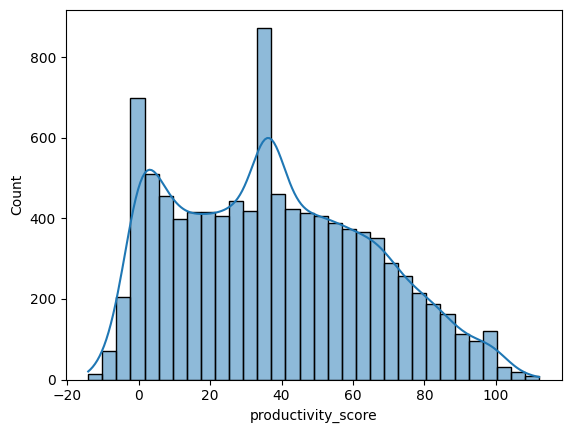

In [35]:
sns.histplot(df_upd["productivity_score"], kde=True)
plt.show()     #show distribution of productivity score

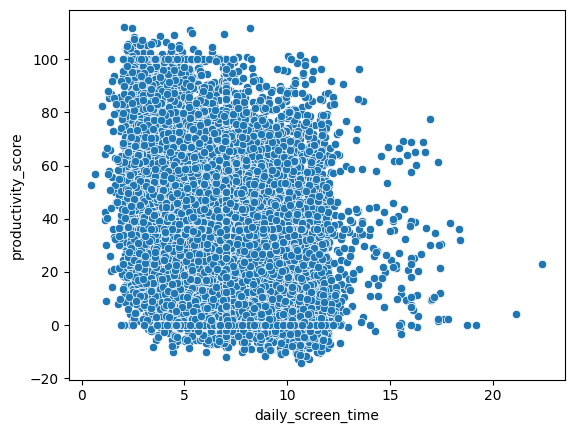

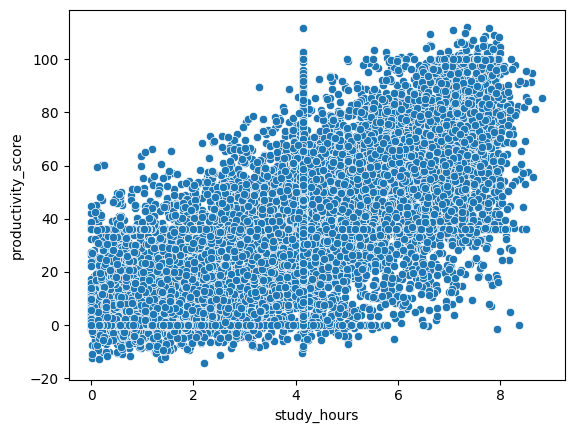

In [36]:
sns.scatterplot(x="daily_screen_time", y="productivity_score", data=df_upd)
plt.show()  #Shows relationship between screen time and productivity.

sns.scatterplot(x="study_hours", y="productivity_score", data=df_upd)
plt.show() #Shows relationship between study hours and productivity.

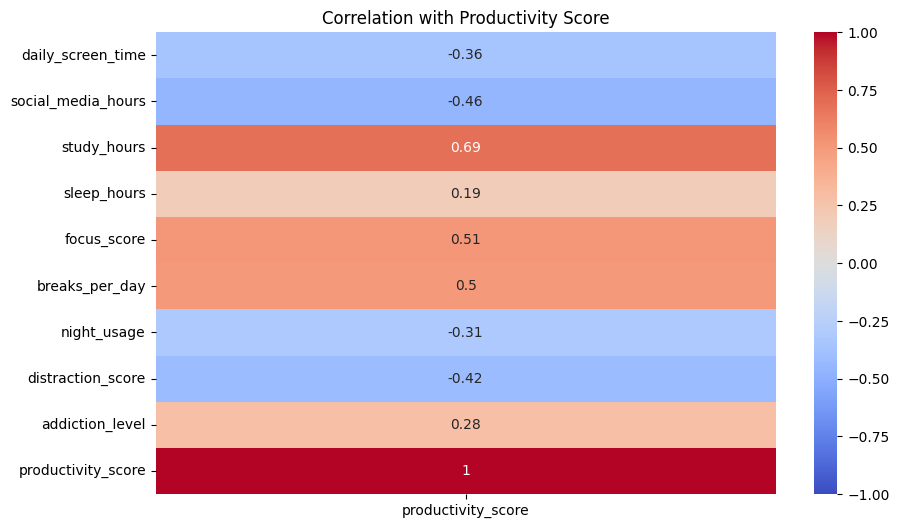

In [37]:
#Displays correlation of all features with productivity score.

plt.figure(figsize=(10,6))

corr_productivity = df_upd.corr(numeric_only=True)[["productivity_score"]]

sns.heatmap(corr_productivity, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Correlation with Productivity Score")
plt.show()

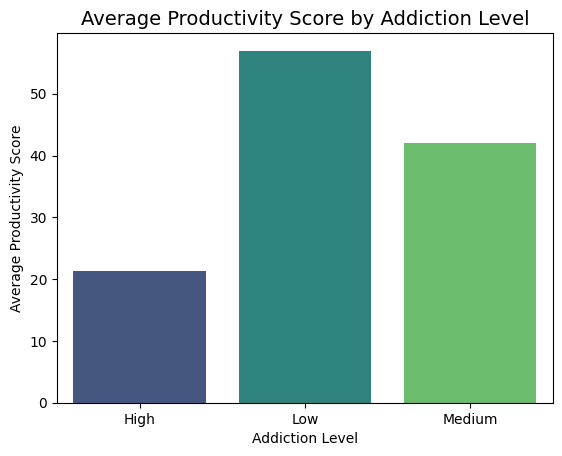

In [38]:
#Computes and visualize average productivity per addiction level .

plt.figure()
mean_prod = df.groupby('addiction_level', as_index=False)['productivity_score'].mean()

sns.barplot(x='addiction_level',
            y='productivity_score',
            data=mean_prod,
            hue='addiction_level',
            palette='viridis',
            legend=False)

plt.title('Average Productivity Score by Addiction Level', fontsize=14)
plt.xlabel('Addiction Level')
plt.ylabel('Average Productivity Score')
plt.show()

In [39]:
#Limits maximum value of focus score to 100 to removes outliers
df_upd['focus_score'] = df_upd['focus_score'].clip(upper=100)

In [40]:
#Create new features
df_upd['study_to_screen_ratio'] = df_upd['study_hours'] / (df_upd['daily_screen_time'] + 0.01)

df_upd['lifestyle_score'] = (df_upd['study_hours'] * 0.35) + \
                           (df_upd['sleep_hours'] * 0.30) + \
                           (df_upd['focus_score'] * 0.25) - \
                           (df_upd['social_media_hours'] * 0.30)

In [41]:
#top important features
corr_with_target = df_upd.corr()['productivity_score'].abs().sort_values(ascending=False)
print("Top features correlated with productivity_score:")
print(corr_with_target.head(12))

Top features correlated with productivity_score:
productivity_score       1.000000
lifestyle_score          0.697969
study_hours              0.686850
study_to_screen_ratio    0.685836
focus_score              0.513559
breaks_per_day           0.495652
social_media_hours       0.458842
distraction_score        0.421808
daily_screen_time        0.356645
night_usage              0.313989
addiction_level          0.281336
sleep_hours              0.192772
Name: productivity_score, dtype: float64


In [42]:
#Random Forest Regressor

X = df_upd.drop("productivity_score", axis=1)
y = df_upd["productivity_score"]

X_train, X_test, y_train, y_test = train_test_split(   #👉 Splits data into training (75%) and testing (25%).
    X, y, test_size=0.25, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,     #num of trees
    max_depth=10,        # limit trees dept from becoming too complex (aviod overfitting)
    min_samples_leaf=5,  # Ensures each leaf has enough data to be reliable
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:", y_pred)

#Evalute Model performance
print("MAE:", mean_absolute_error(y_test, y_pred))  #Average of the absolute differences between actual and predicted values
print("R2 Score:", r2_score(y_test, y_pred))


#Checks training vs testing accuracy (overfitting detection)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

Predictions: [18.8625544  49.83748017 48.62812827 ... 29.14288143 30.48954166
  7.9707441 ]
MAE: 10.094807816866618
MSE: 175.4398323924216
R2 Score: 0.7628386761231554
0.8594845563534561
0.7628386761231554


In [43]:
#Decision Tree Regressor

modelR = DecisionTreeRegressor(criterion="squared_error", max_depth= 7, random_state=42)
modelR.fit(X_train, y_train)


R_pred = modelR.predict(X_test)

print("MAE:", mean_absolute_error(y_test, R_pred))
print("R2 Score:", r2_score(y_test, R_pred))

print(modelR.score(X_train, y_train))
print(modelR.score(X_test, y_test))


MAE: 10.89514928030799
MSE: 205.2667347374135
R2 Score: 0.722518370575547
0.7846480502413515
0.722518370575547


In [44]:
#Initializes scaler for normalization ,imp for KNN and linear regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
#KNN model

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("--- KNN Results ---")
print("MAE:", mean_absolute_error(y_test, knn_pred))
print("R2 Score:", r2_score(y_test, knn_pred))
print("KNN Train Score:", knn_model.score(X_train_scaled, y_train))
print("KNN Test Score:", knn_model.score(X_test_scaled, y_test))

--- KNN Results ---
MAE: 10.82741872018168
R2 Score: 0.7349797521769972
KNN Train Score: 0.8225395852631529
KNN Test Score: 0.7349797521769972


In [46]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


lr_pred = lr_model.predict(X_test_scaled)

print("--- Linear Regression Results ---")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))
print("LR Train Score:", lr_model.score(X_train_scaled, y_train))
print("LR Test Score:", lr_model.score(X_test_scaled, y_test))

--- Linear Regression Results ---
MAE: 10.742810040817597
R2 Score: 0.7408179912596176
LR Train Score: 0.7421455902963228
LR Test Score: 0.7408179912596176
